In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from infomap import Infomap
import pickle
import sys
sys.path.insert(1, '../')
from Harmonic_degree import *

In [2]:
print(nx.__version__)

3.4.2


# DATA 1

In [3]:
# Labels of data frames
Col_labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
Row_labels= ["LabProp.", "Gr. Mod." , "Louv." , "Imap", "B SBM"]

In [4]:
# Save data
#with open("GT_Tools_producing_data/Intermediate_outputs_1/data_1.pkl", "wb") as f:
    #pickle.dump(data_1, f)

In [5]:
# Open data
with open("GT_Tools_producing_data/Intermediate_outputs_1/data_1.pkl", "rb") as f:
    data_1 = pickle.load(f)

In [6]:
# Load sbm_1
with open("GT_Tools_producing_data/Intermediate_outputs_1/sbm_1.pkl", "rb") as f:
    sbm_1 = pickle.load(f)

In [62]:
df_1 = {}
df_1_ext={}
for name, g in data_1.items():
    # label propagation
    lb = nx.community.label_propagation_communities(g)
    cl_lb = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lb):
        for node in cluster_nodes:
            cl_lb[node] = cluster_id  # Assign cluster ID to node

    # greedy modularity
    nw = nx.community.greedy_modularity_communities(g)
    cl_nw = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(nw):
        for node in cluster_nodes:
            cl_nw[node] = cluster_id  # Assign cluster ID to node

    # Louvain
    lv=nx.community.louvain_communities(g)
    cl_lv = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lv):
        for node in cluster_nodes:
            cl_lv[node] = cluster_id  # Assign cluster ID to node
            
    # Infomap
    im= Infomap(two_level=True,silent=True, num_trials=20)
    im.add_networkx_graph(g)
    im.run()
    info = im.get_modules()
    
    # Bayesian SBM
    sbm = sbm_1[name]

    # Compute harmonic degrees
    G_lb, deg_h_lb, M_deg_h_lb, var_h_lb, av_h_lb, var_v_h_lb, Not_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb, av_cf_lb, var_v_cf_lb, Not_cf_lb= H_CF_cluster(g,cl_lb)
    G_nw, deg_h_nw, M_deg_h_nw, var_h_nw, av_h_nw, var_v_h_nw, Not_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw, av_cf_nw, var_v_cf_nw, Not_cf_nw= H_CF_cluster(g,cl_nw)
    G_lv, deg_h_lv, M_deg_h_lv, var_h_lv, av_h_lv, var_v_h_lv, Not_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv, av_cf_lv, var_v_cf_lv, Not_cf_lv= H_CF_cluster(g,cl_lv)
    G_im, deg_h_im, M_deg_h_im, var_h_im, av_h_im, var_v_h_im, Not_h_im, deg_cf_im, M_deg_cf_im, var_cf_im, av_cf_im, var_v_cf_im, Not_cf_im= H_CF_cluster(g,info)
    G_sbm, deg_h_sbm, M_deg_h_sbm, var_h_sbm, av_h_sbm, var_v_h_sbm, Not_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm, av_cf_sbm, var_v_cf_sbm, Not_cf_sbm= H_CF_cluster(g,sbm)
    # storing results in a dataframe
    val_lb = [deg_h_lb, M_deg_h_lb, var_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb]
    val_nw = [deg_h_nw, M_deg_h_nw, var_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw]
    val_lv = [deg_h_lv, M_deg_h_lv, var_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv]
    val_im = [deg_h_im, M_deg_h_im, var_h_im, deg_cf_im, M_deg_cf_im, var_cf_im]
    val_sbm = [deg_h_sbm, M_deg_h_sbm, var_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm]
    val = [ val_lb,val_nw, val_lv, val_im, val_sbm]
    df_ext = pd.DataFrame(val, index= Row_labels,  columns = Col_labels)
    df = df_ext.iloc[:, :3]
    df_1[name] = df
    df_1_ext[name] = df_ext
    print("ok")

ok
ok
ok
ok
ok
ok


In [63]:
# Save the dictionary to a .pkl file
with open("Final_outputs/df_1.pkl", "wb") as f:
    pickle.dump(df_1, f)

# Save the dictionary to a .pkl file
with open("Final_outputs/df_1_ext.pkl", "wb") as f:
    pickle.dump(df_1_ext, f)

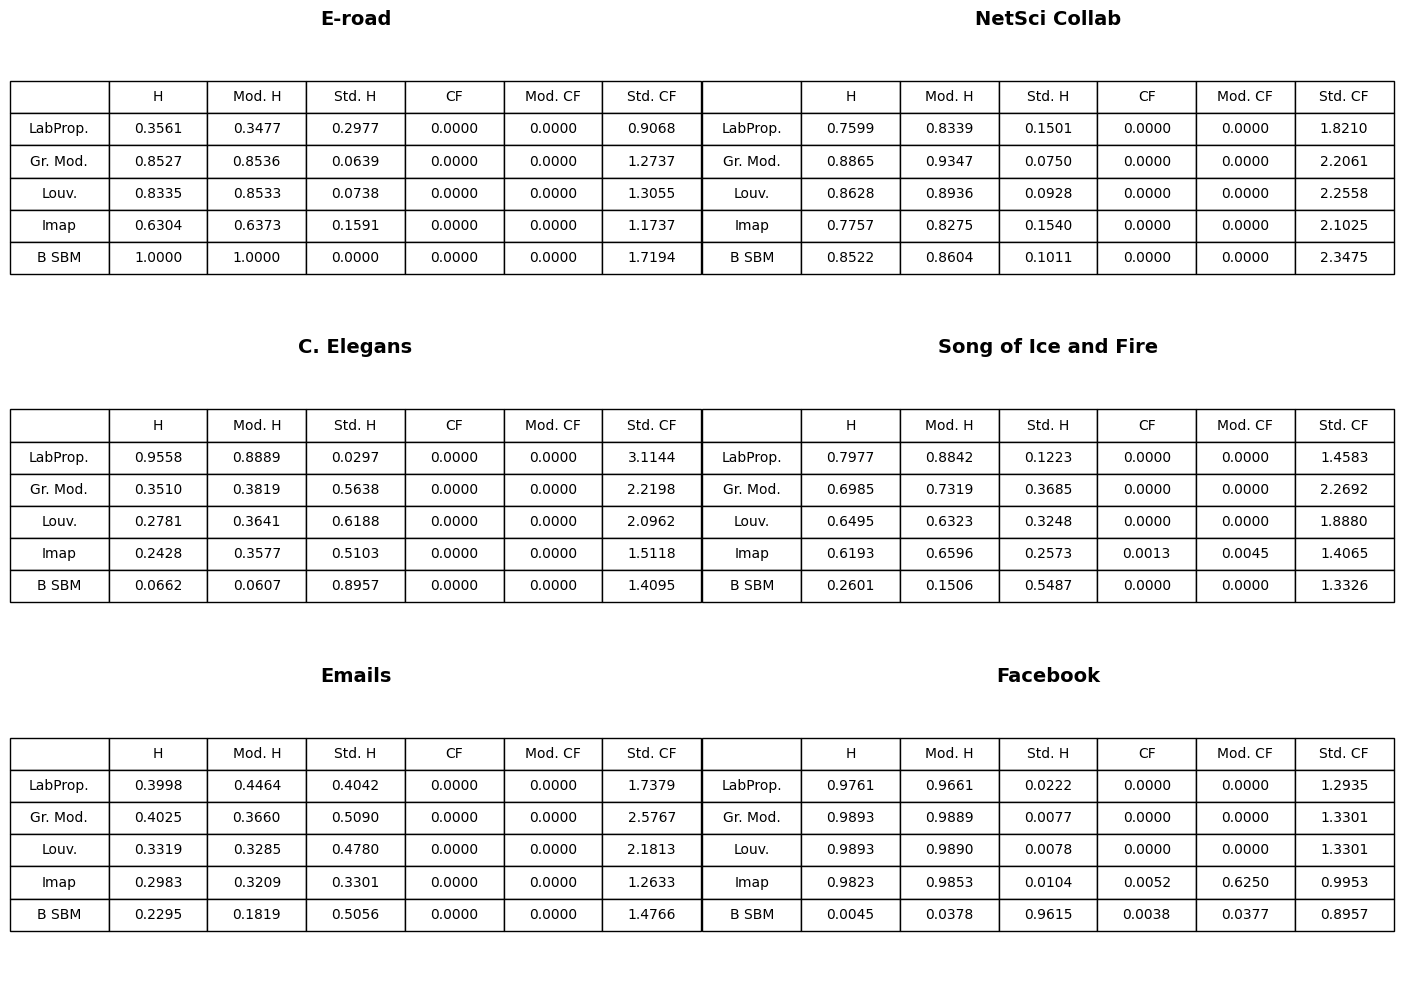

In [64]:
# Create a 2x3 subplot with an increased figure size
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
# Loop through DataFrames and display them in the subplot
for i, (title, df) in enumerate(df_1_ext.items()):
    axes[i].axis("off")  # Hide axes
    # Format values to 4 decimal places
    formatted_data = df.applymap(lambda x: f"{x:.4f}")
    # Convert DataFrame to include row labels
    table_data = formatted_data.copy()
    table_data.insert(0, "Index", table_data.index)  # Add row labels as first column
    # Create table with row and column labels
    table = axes[i].table(
        cellText=table_data.values,  # Data with row labels
        colLabels=[""] + list(df.columns),  # Empty first column for row labels
        cellLoc="center", 
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)  # Adjust table scaling
    # Set title closer to the table
    axes[i].set_title(title, fontsize=14, fontweight="bold", pad=5)
# Adjust layout to fit everything
plt.subplots_adjust(wspace=0.2, hspace=0.8)
plt.tight_layout()

# Protein by Tissues

In [90]:
# Labels of data frames
Col_labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
Row_labels= ["LabProp.", "Gr. Mod." , "Louv." , "Imap", "B SBM"]

In [7]:
# opening files
with open("GT_Tools_producing_data/Intermediate_outputs_2/data_2.pkl", "rb") as f:
    data_2 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_2/sbm_2.pkl", "rb") as f:
    sbm_2 = pickle.load(f)


In [92]:
df_2 = {}
df_2_ext={}
for name, g in data_2.items():
    # label propagation
    lb = nx.community.label_propagation_communities(g)
    cl_lb = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lb):
        for node in cluster_nodes:
            cl_lb[node] = cluster_id  # Assign cluster ID to node

    # greedy modularity
    nw = nx.community.greedy_modularity_communities(g)
    cl_nw = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(nw):
        for node in cluster_nodes:
            cl_nw[node] = cluster_id  # Assign cluster ID to node

    # Louvain
    lv= nx.community.louvain_communities(g)
    cl_lv = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lv):
        for node in cluster_nodes:
            cl_lv[node] = cluster_id  # Assign cluster ID to node
            
    # Infomap
    im= Infomap(two_level=True,silent=True, num_trials=20)
    im.add_networkx_graph(g)
    im.run()
    info = im.get_modules()
    
    # Bayesian SBM
    sbm = sbm_2[name]

    # Compute harmonic degrees
    G_lb, deg_h_lb, M_deg_h_lb, var_h_lb, av_h_lb, var_v_h_lb, Not_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb, av_cf_lb, var_v_cf_lb, Not_cf_lb= H_CF_cluster(g,cl_lb)
    G_nw, deg_h_nw, M_deg_h_nw, var_h_nw, av_h_nw, var_v_h_nw, Not_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw, av_cf_nw, var_v_cf_nw, Not_cf_nw= H_CF_cluster(g,cl_nw)
    G_lv, deg_h_lv, M_deg_h_lv, var_h_lv, av_h_lv, var_v_h_lv, Not_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv, av_cf_lv, var_v_cf_lv, Not_cf_lv= H_CF_cluster(g,cl_lv)
    G_im, deg_h_im, M_deg_h_im, var_h_im, av_h_im, var_v_h_im, Not_h_im, deg_cf_im, M_deg_cf_im, var_cf_im, av_cf_im, var_v_cf_im, Not_cf_im= H_CF_cluster(g,info)
    G_sbm, deg_h_sbm, M_deg_h_sbm, var_h_sbm, av_h_sbm, var_v_h_sbm, Not_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm, av_cf_sbm, var_v_cf_sbm, Not_cf_sbm= H_CF_cluster(g,sbm)
    # storing results in a dataframe
    val_lb = [deg_h_lb, M_deg_h_lb, var_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb]
    val_nw = [deg_h_nw, M_deg_h_nw, var_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw]
    val_lv = [deg_h_lv, M_deg_h_lv, var_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv]
    val_im = [deg_h_im, M_deg_h_im, var_h_im, deg_cf_im, M_deg_cf_im, var_cf_im]
    val_sbm = [deg_h_sbm, M_deg_h_sbm, var_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm]
    val = [ val_lb,val_nw, val_lv, val_im, val_sbm]
    df_ext = pd.DataFrame(val, index= Row_labels,  columns = Col_labels)
    df = df_ext.iloc[:, :3]
    df_2[name] = df
    df_2_ext[name] = df_ext
    print("ok")

ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok


In [93]:
# Save the dictionary to a .pkl file
with open("Final_outputs/df_2.pkl", "wb") as f:
    pickle.dump(df_2, f)

# Save the dictionary to a .pkl file
with open("Final_outputs/df_2_ext.pkl", "wb") as f:
    pickle.dump(df_2_ext, f)

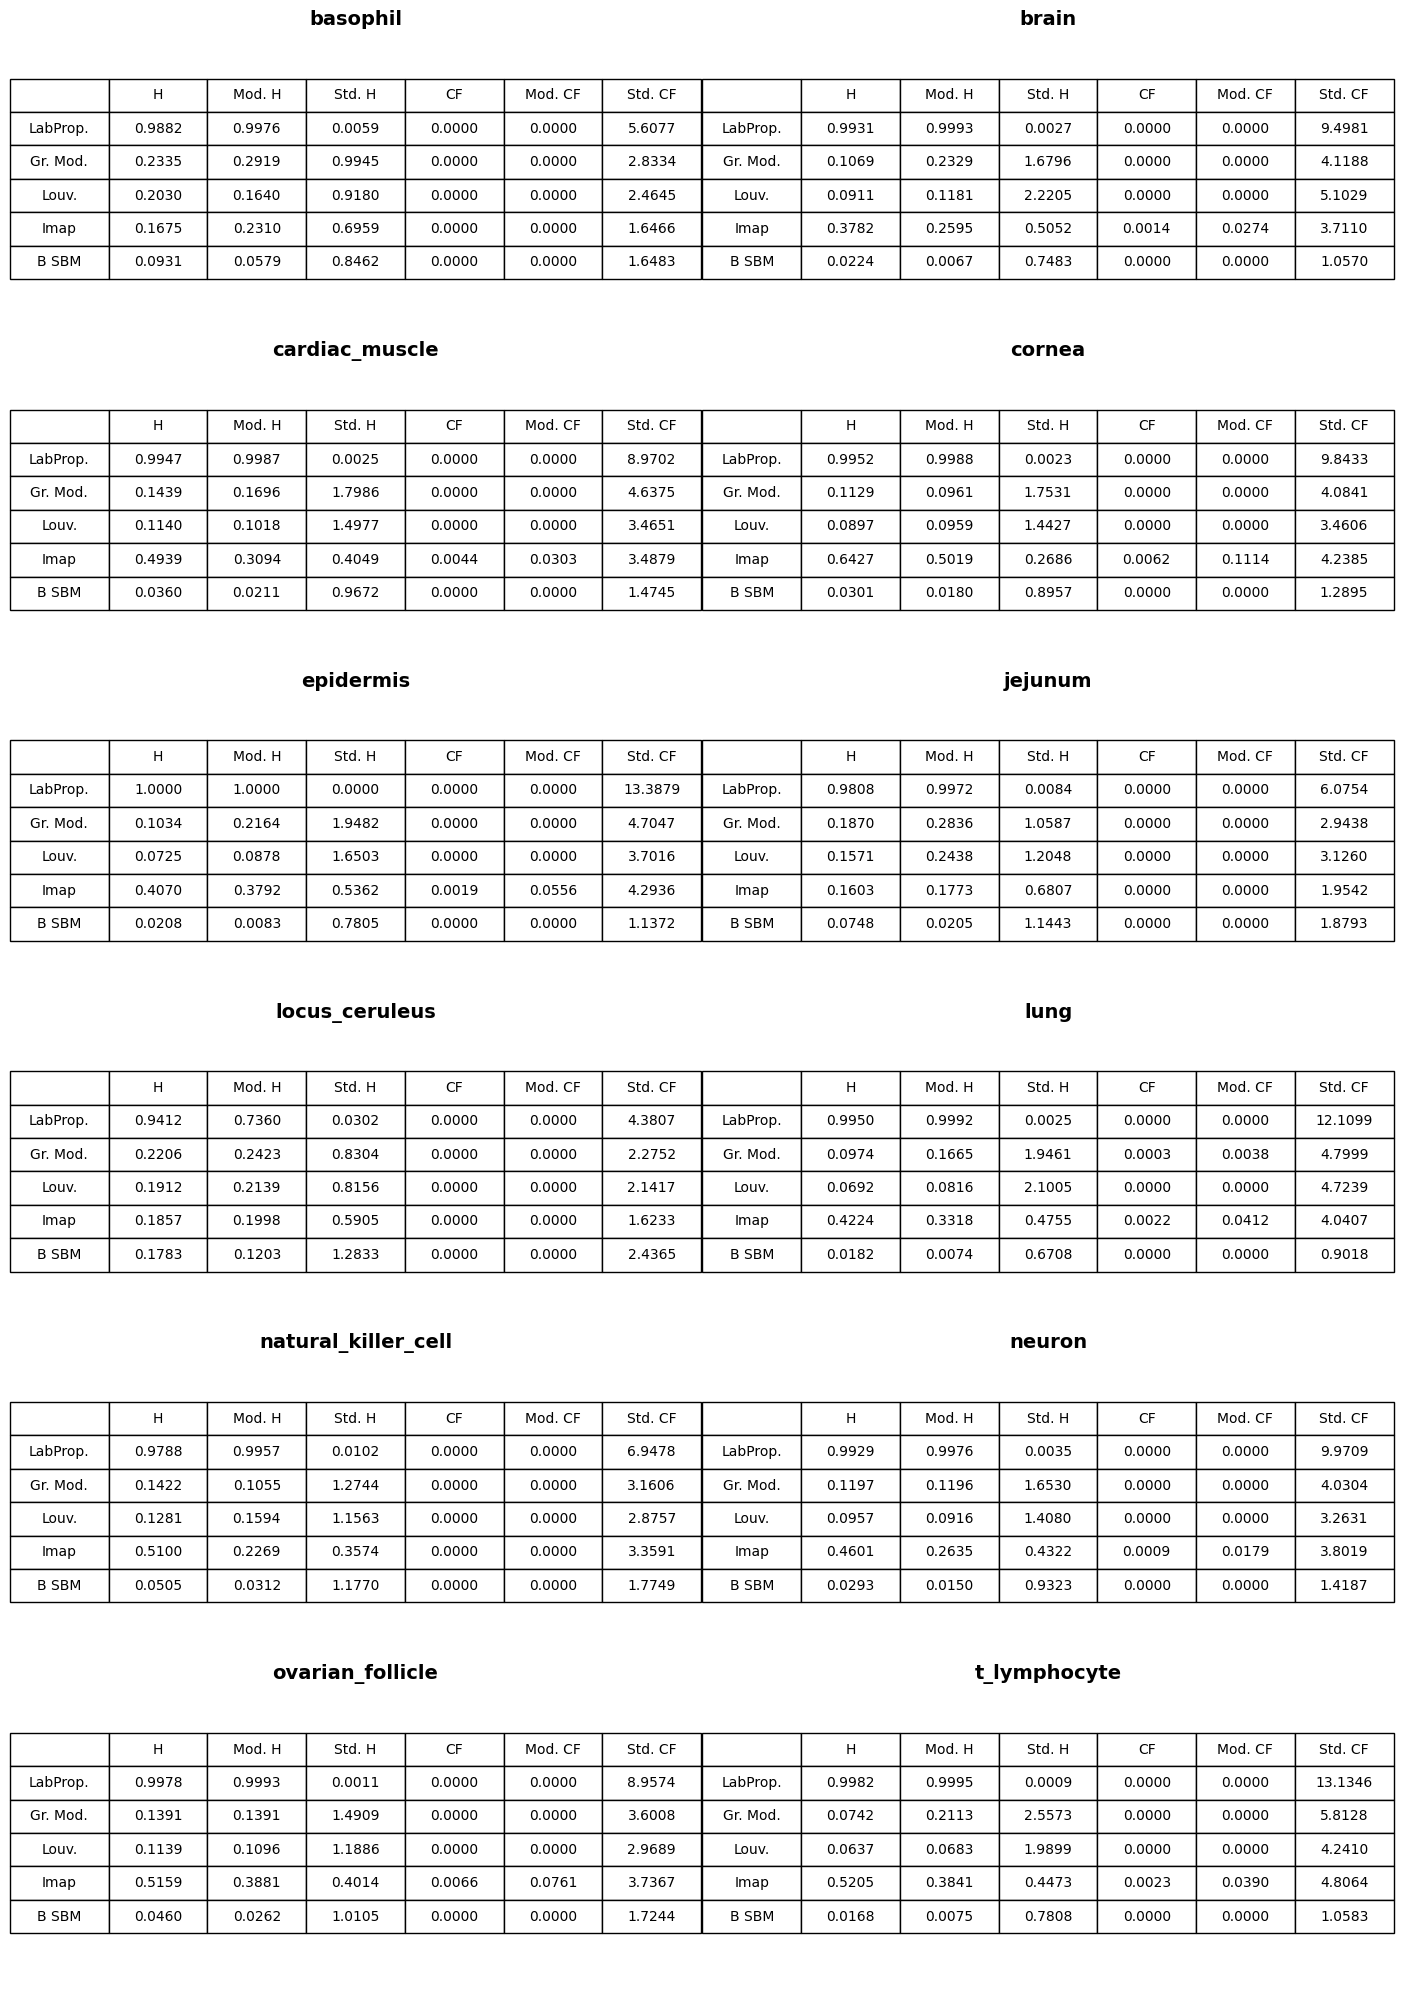

In [94]:
# Create a 2x3 subplot with an increased figure size
fig, axes = plt.subplots(6, 2, figsize=(14, 20))
axes = axes.flatten()
# Loop through DataFrames and display them in the subplot
for i, (title, df) in enumerate(df_2_ext.items()):
    axes[i].axis("off")  # Hide axes
    # Format values to 4 decimal places
    formatted_data = df.applymap(lambda x: f"{x:.4f}")
    # Convert DataFrame to include row labels
    table_data = formatted_data.copy()
    table_data.insert(0, "Index", table_data.index)  # Add row labels as first column
    # Create table with row and column labels
    table = axes[i].table(
        cellText=table_data.values,  # Data with row labels
        colLabels=[""] + list(df.columns),  # Empty first column for row labels
        cellLoc="center", 
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)  # Adjust table scaling
    # Set title closer to the table
    axes[i].set_title(title, fontsize=14, fontweight="bold", pad=5)
# Adjust layout to fit everything
plt.subplots_adjust(wspace=0.2, hspace=0.8)
plt.tight_layout()

# Data 3

In [8]:
# opening files
with open("GT_Tools_producing_data/Intermediate_outputs_3/data_3.pkl", "rb") as f:
    data_3 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_3/sbm_3.pkl", "rb") as f:
    sbm_3 = pickle.load(f)

print(len(data_3))
print(len(sbm_3))

3
3


In [71]:
df_3 = {}
df_3_ext={}
for name, g in data_3.items():
    # label propagation
    lb = nx.community.label_propagation_communities(g)
    cl_lb = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lb):
        for node in cluster_nodes:
            cl_lb[node] = cluster_id  # Assign cluster ID to node

    # greedy modularity
    nw = nx.community.greedy_modularity_communities(g)
    cl_nw = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(nw):
        for node in cluster_nodes:
            cl_nw[node] = cluster_id  # Assign cluster ID to node

    # Louvain
    lv= nx.community.louvain_communities(g)
    cl_lv = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lv):
        for node in cluster_nodes:
            cl_lv[node] = cluster_id  # Assign cluster ID to node
            
    # Infomap
    im= Infomap(two_level=True,silent=True, num_trials=20)
    im.add_networkx_graph(g)
    im.run()
    info = im.get_modules()
    
    # Bayesian SBM
    sbm = sbm_3[name]

    # Compute harmonic degrees
    G_lb, deg_h_lb, M_deg_h_lb, var_h_lb, av_h_lb, var_v_h_lb, Not_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb, av_cf_lb, var_v_cf_lb, Not_cf_lb= H_CF_cluster(g,cl_lb)
    G_nw, deg_h_nw, M_deg_h_nw, var_h_nw, av_h_nw, var_v_h_nw, Not_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw, av_cf_nw, var_v_cf_nw, Not_cf_nw= H_CF_cluster(g,cl_nw)
    G_lv, deg_h_lv, M_deg_h_lv, var_h_lv, av_h_lv, var_v_h_lv, Not_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv, av_cf_lv, var_v_cf_lv, Not_cf_lv= H_CF_cluster(g,cl_lv)
    G_im, deg_h_im, M_deg_h_im, var_h_im, av_h_im, var_v_h_im, Not_h_im, deg_cf_im, M_deg_cf_im, var_cf_im, av_cf_im, var_v_cf_im, Not_cf_im= H_CF_cluster(g,info)
    G_sbm, deg_h_sbm, M_deg_h_sbm, var_h_sbm, av_h_sbm, var_v_h_sbm, Not_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm, av_cf_sbm, var_v_cf_sbm, Not_cf_sbm= H_CF_cluster(g,sbm)
    # storing results in a dataframe
    val_lb = [deg_h_lb, M_deg_h_lb, var_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb]
    val_nw = [deg_h_nw, M_deg_h_nw, var_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw]
    val_lv = [deg_h_lv, M_deg_h_lv, var_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv]
    val_im = [deg_h_im, M_deg_h_im, var_h_im, deg_cf_im, M_deg_cf_im, var_cf_im]
    val_sbm = [deg_h_sbm, M_deg_h_sbm, var_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm]
    val = [ val_lb,val_nw, val_lv, val_im, val_sbm]
    df_ext = pd.DataFrame(val, index= Row_labels,  columns = Col_labels)
    df = df_ext.iloc[:, :3]
    df_3[name] = df
    df_3_ext[name] = df_ext
    print("ok")

ok
ok
ok


In [72]:
# Save the dictionary to a .pkl file
with open("Final_outputs/df_3.pkl", "wb") as f:
    pickle.dump(df_3, f)

# Save the dictionary to a .pkl file
with open("Final_outputs/df_3_ext.pkl", "wb") as f:
    pickle.dump(df_3_ext, f)

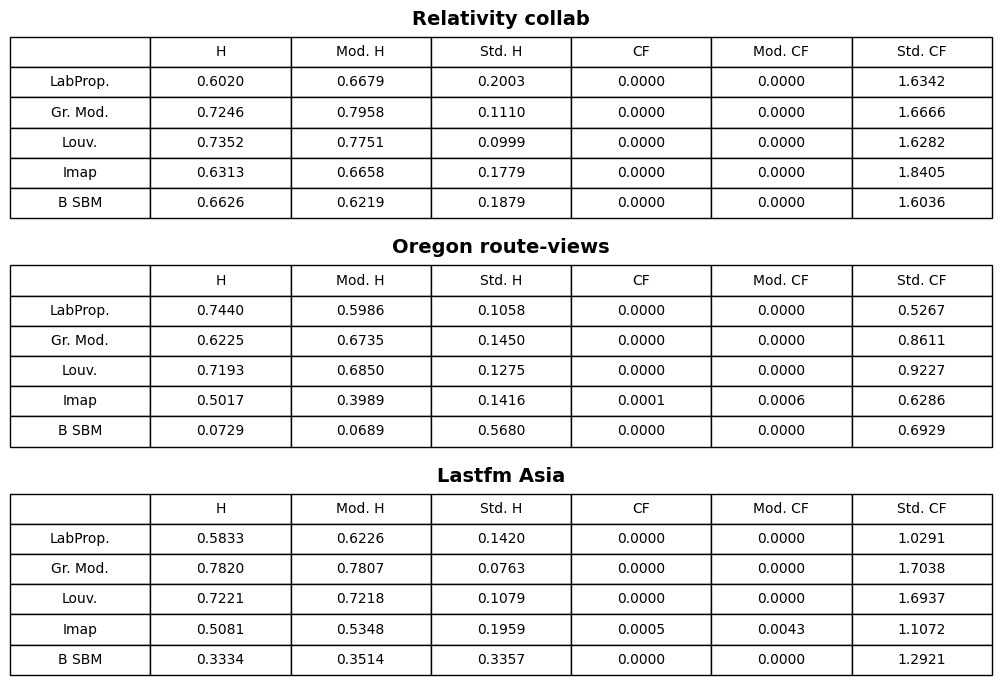

In [73]:
# Create a 2x3 subplot with an increased figure size
fig, axes = plt.subplots(3, 1, figsize=(10, 7))
axes = axes.flatten()
# Loop through DataFrames and display them in the subplot
for i, (title, df) in enumerate(df_3_ext.items()):
    axes[i].axis("off")  # Hide axes
    # Format values to 4 decimal places
    formatted_data = df.applymap(lambda x: f"{x:.4f}")
    # Convert DataFrame to include row labels
    table_data = formatted_data.copy()
    table_data.insert(0, "Index", table_data.index)  # Add row labels as first column
    # Create table with row and column labels
    table = axes[i].table(
        cellText=table_data.values,  # Data with row labels
        colLabels=[""] + list(df.columns),  # Empty first column for row labels
        cellLoc="center", 
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)  # Adjust table scaling
    # Set title closer to the table
    axes[i].set_title(title, fontsize=14, fontweight="bold", pad=5)
# Adjust layout to fit everything
plt.subplots_adjust(wspace=0.2, hspace=0.8)
plt.tight_layout()

# Data 4

In [9]:
# opening files
with open("GT_Tools_producing_data/Intermediate_outputs_4/data_4.pkl", "rb") as f:
    data_4 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_4/sbm_4.pkl", "rb") as f:
    sbm_4 = pickle.load(f)

print(len(data_4))
print(len(sbm_4))

8
8


In [75]:
df_4_ext={}
df_4 = {}
for name, g in data_4.items():
    # label propagation
    lb = nx.community.label_propagation_communities(g)
    cl_lb = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lb):
        for node in cluster_nodes:
            cl_lb[node] = cluster_id  # Assign cluster ID to node

    # greedy modularity
    nw = nx.community.greedy_modularity_communities(g)
    cl_nw = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(nw):
        for node in cluster_nodes:
            cl_nw[node] = cluster_id  # Assign cluster ID to node

    # Louvain
    lv= nx.community.louvain_communities(g)
    cl_lv = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lv):
        for node in cluster_nodes:
            cl_lv[node] = cluster_id  # Assign cluster ID to node
            
    # Infomap
    im= Infomap(two_level=True,silent=True, num_trials=20)
    im.add_networkx_graph(g)
    im.run()
    info = im.get_modules()
    
    # Bayesian SBM
    sbm = sbm_4[name]

    # Compute harmonic degrees
    G_lb, deg_h_lb, M_deg_h_lb, var_h_lb, av_h_lb, var_v_h_lb, Not_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb, av_cf_lb, var_v_cf_lb, Not_cf_lb= H_CF_cluster(g,cl_lb)
    G_nw, deg_h_nw, M_deg_h_nw, var_h_nw, av_h_nw, var_v_h_nw, Not_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw, av_cf_nw, var_v_cf_nw, Not_cf_nw= H_CF_cluster(g,cl_nw)
    G_lv, deg_h_lv, M_deg_h_lv, var_h_lv, av_h_lv, var_v_h_lv, Not_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv, av_cf_lv, var_v_cf_lv, Not_cf_lv= H_CF_cluster(g,cl_lv)
    G_im, deg_h_im, M_deg_h_im, var_h_im, av_h_im, var_v_h_im, Not_h_im, deg_cf_im, M_deg_cf_im, var_cf_im, av_cf_im, var_v_cf_im, Not_cf_im= H_CF_cluster(g,info)
    G_sbm, deg_h_sbm, M_deg_h_sbm, var_h_sbm, av_h_sbm, var_v_h_sbm, Not_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm, av_cf_sbm, var_v_cf_sbm, Not_cf_sbm= H_CF_cluster(g,sbm)
    # storing results in a dataframe
    val_lb = [deg_h_lb, M_deg_h_lb, var_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb]
    val_nw = [deg_h_nw, M_deg_h_nw, var_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw]
    val_lv = [deg_h_lv, M_deg_h_lv, var_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv]
    val_im = [deg_h_im, M_deg_h_im, var_h_im, deg_cf_im, M_deg_cf_im, var_cf_im]
    val_sbm = [deg_h_sbm, M_deg_h_sbm, var_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm]
    val = [ val_lb,val_nw, val_lv, val_im, val_sbm]
    df_ext = pd.DataFrame(val, index= Row_labels,  columns = Col_labels)
    df = df_ext.iloc[:, :3]
    df_4[name] = df
    df_4_ext[name] = df_ext
    print("ok")

ok
ok
ok
ok
ok
ok
ok
ok


In [76]:
# Save the dictionary to a .pkl file
with open("Final_outputs/df_4.pkl", "wb") as f:
    pickle.dump(df_4, f)

# Save the dictionary to a .pkl file
with open("Final_outputs/df_4_ext.pkl", "wb") as f:
    pickle.dump(df_4_ext, f)

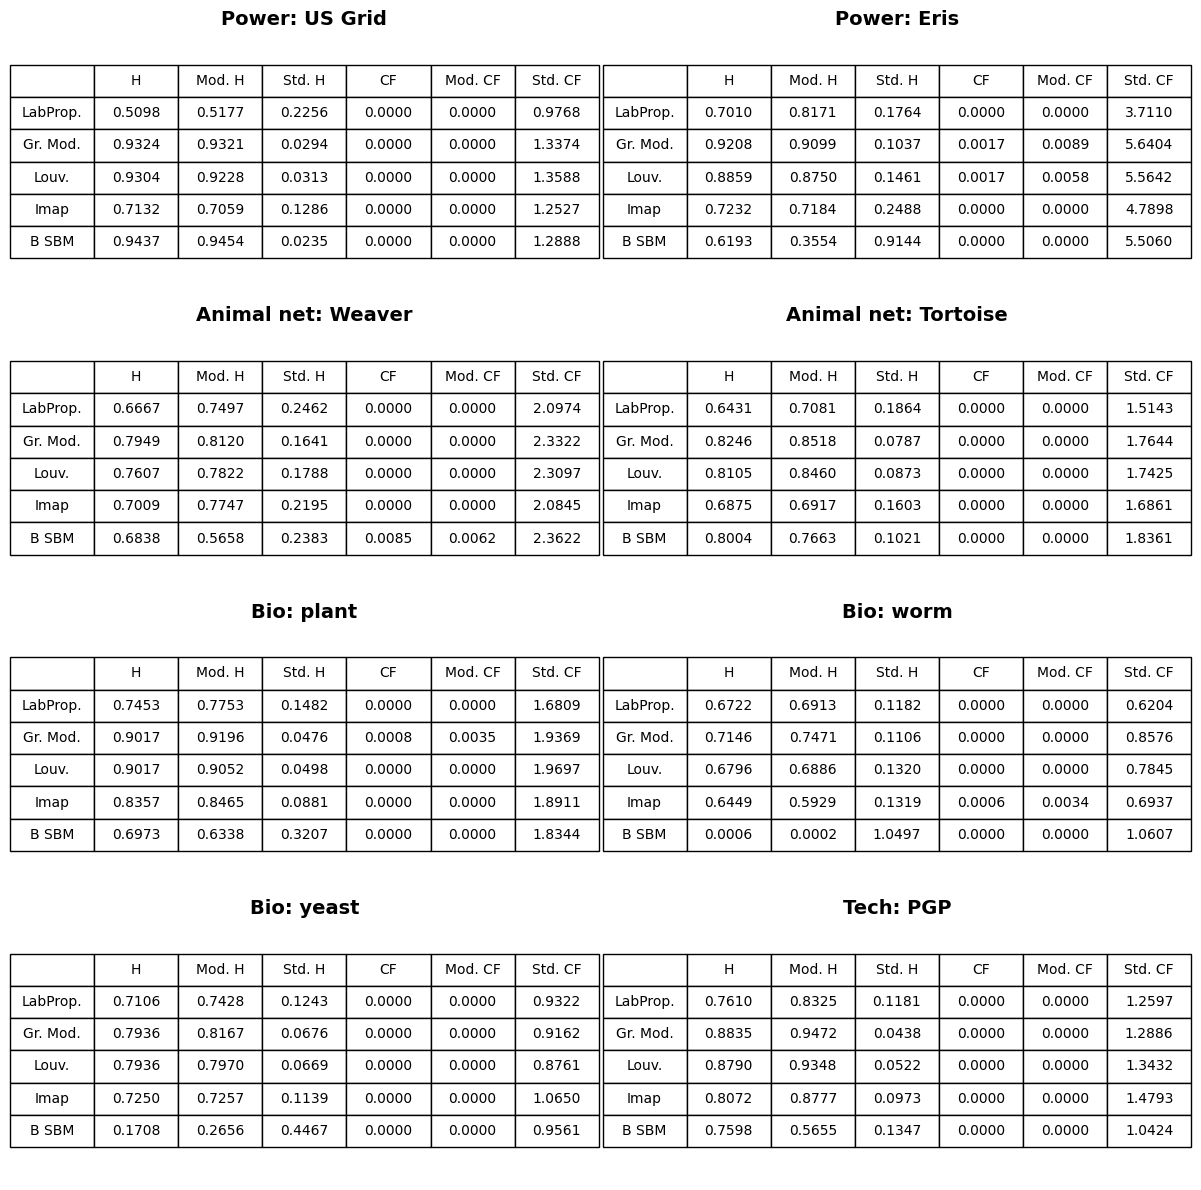

In [77]:
# Create a 2x3 subplot with an increased figure size
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()
# Loop through DataFrames and display them in the subplot
for i, (title, df) in enumerate(df_4_ext.items()):
    axes[i].axis("off")  # Hide axes
    # Format values to 4 decimal places
    formatted_data = df.applymap(lambda x: f"{x:.4f}")
    # Convert DataFrame to include row labels
    table_data = formatted_data.copy()
    table_data.insert(0, "Index", table_data.index)  # Add row labels as first column
    # Create table with row and column labels
    table = axes[i].table(
        cellText=table_data.values,  # Data with row labels
        colLabels=[""] + list(df.columns),  # Empty first column for row labels
        cellLoc="center", 
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)  # Adjust table scaling
    # Set title closer to the table
    axes[i].set_title(title, fontsize=14, fontweight="bold", pad=5)
# Adjust layout to fit everything
plt.subplots_adjust(wspace=0.2, hspace=0.8)
plt.tight_layout()

# Data 5

In [10]:
# opening files
with open("GT_Tools_producing_data/Intermediate_outputs_5/data_5.pkl", "rb") as f:
    data_5 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_5/sbm_5.pkl", "rb") as f:
    sbm_5 = pickle.load(f)

print(len(data_5))
print(len(sbm_5))

8
8


In [79]:
df_5_ext={}
df_5= {}
for name, g in data_5.items():
    # label propagation
    lb = nx.community.label_propagation_communities(g)
    cl_lb = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lb):
        for node in cluster_nodes:
            cl_lb[node] = cluster_id  # Assign cluster ID to node

    # greedy modularity
    nw = nx.community.greedy_modularity_communities(g)
    cl_nw = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(nw):
        for node in cluster_nodes:
            cl_nw[node] = cluster_id  # Assign cluster ID to node

    # Louvain
    lv= nx.community.louvain_communities(g)
    cl_lv = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lv):
        for node in cluster_nodes:
            cl_lv[node] = cluster_id  # Assign cluster ID to node
            
    # Infomap
    im= Infomap(two_level=True,silent=True, num_trials=20)
    im.add_networkx_graph(g)
    im.run()
    info = im.get_modules()
    
    # Bayesian SBM
    sbm = sbm_5[name]

    # Compute harmonic degrees
    G_lb, deg_h_lb, M_deg_h_lb, var_h_lb, av_h_lb, var_v_h_lb, Not_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb, av_cf_lb, var_v_cf_lb, Not_cf_lb= H_CF_cluster(g,cl_lb)
    G_nw, deg_h_nw, M_deg_h_nw, var_h_nw, av_h_nw, var_v_h_nw, Not_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw, av_cf_nw, var_v_cf_nw, Not_cf_nw= H_CF_cluster(g,cl_nw)
    G_lv, deg_h_lv, M_deg_h_lv, var_h_lv, av_h_lv, var_v_h_lv, Not_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv, av_cf_lv, var_v_cf_lv, Not_cf_lv= H_CF_cluster(g,cl_lv)
    G_im, deg_h_im, M_deg_h_im, var_h_im, av_h_im, var_v_h_im, Not_h_im, deg_cf_im, M_deg_cf_im, var_cf_im, av_cf_im, var_v_cf_im, Not_cf_im= H_CF_cluster(g,info)
    G_sbm, deg_h_sbm, M_deg_h_sbm, var_h_sbm, av_h_sbm, var_v_h_sbm, Not_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm, av_cf_sbm, var_v_cf_sbm, Not_cf_sbm= H_CF_cluster(g,sbm)
    # storing results in a dataframe
    val_lb = [deg_h_lb, M_deg_h_lb, var_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb]
    val_nw = [deg_h_nw, M_deg_h_nw, var_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw]
    val_lv = [deg_h_lv, M_deg_h_lv, var_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv]
    val_im = [deg_h_im, M_deg_h_im, var_h_im, deg_cf_im, M_deg_cf_im, var_cf_im]
    val_sbm = [deg_h_sbm, M_deg_h_sbm, var_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm]
    val = [ val_lb,val_nw, val_lv, val_im, val_sbm]
    df_ext = pd.DataFrame(val, index= Row_labels,  columns = Col_labels)
    df = df_ext.iloc[:, :3]
    df_5[name] = df
    df_5_ext[name] = df_ext
    print("ok")

ok
ok
ok
ok
ok
ok
ok
ok


In [80]:
# Save the dictionary to a .pkl file
with open("Final_outputs/df_5.pkl", "wb") as f:
    pickle.dump(df_5, f)

# Save the dictionary to a .pkl file
with open("Final_outputs/df_5_ext.pkl", "wb") as f:
    pickle.dump(df_5_ext, f)

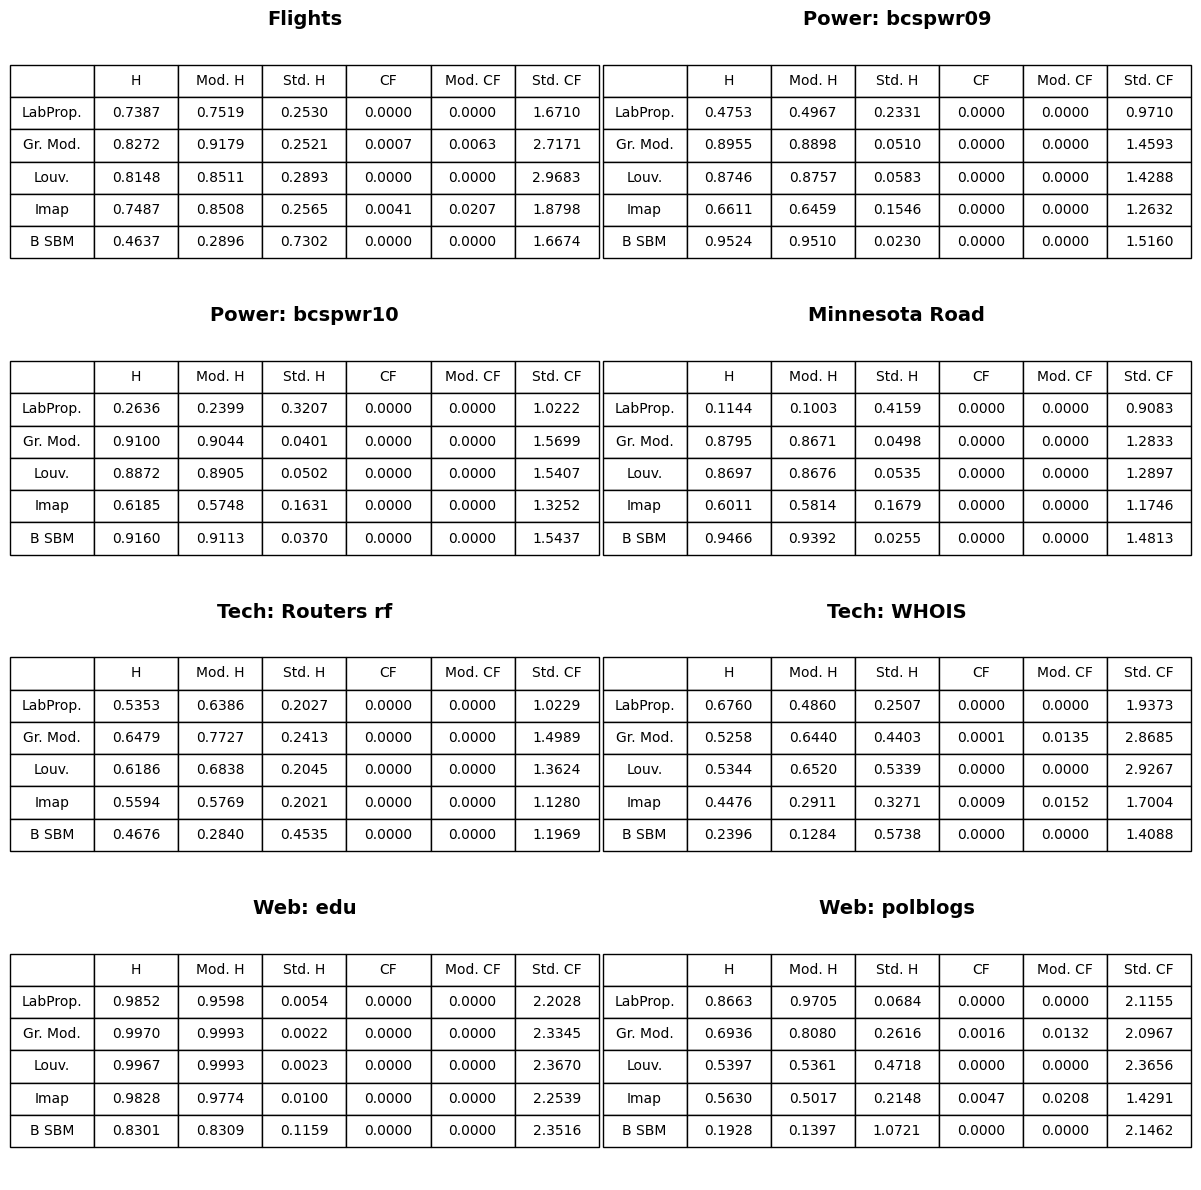

In [81]:
# Create a 2x3 subplot with an increased figure size
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()
# Loop through DataFrames and display them in the subplot
for i, (title, df) in enumerate(df_5_ext.items()):
    axes[i].axis("off")  # Hide axes
    # Format values to 4 decimal places
    formatted_data = df.applymap(lambda x: f"{x:.4f}")
    # Convert DataFrame to include row labels
    table_data = formatted_data.copy()
    table_data.insert(0, "Index", table_data.index)  # Add row labels as first column
    # Create table with row and column labels
    table = axes[i].table(
        cellText=table_data.values,  # Data with row labels
        colLabels=[""] + list(df.columns),  # Empty first column for row labels
        cellLoc="center", 
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)  # Adjust table scaling
    # Set title closer to the table
    axes[i].set_title(title, fontsize=14, fontweight="bold", pad=5)
# Adjust layout to fit everything
plt.subplots_adjust(wspace=0.2, hspace=0.8)
plt.tight_layout()

# Data 6

In [11]:
# opening files
with open("GT_Tools_producing_data/Intermediate_outputs_6/data_6.pkl", "rb") as f:
    data_6= pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_6/sbm_6.pkl", "rb") as f:
    sbm_6 = pickle.load(f)

print(len(data_6))
print(len(sbm_6))

10
10


In [6]:
df_6_ext={}
df_6= {}
for name, g in data_6.items():
    # label propagation
    lb = nx.community.label_propagation_communities(g)
    cl_lb = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lb):
        for node in cluster_nodes:
            cl_lb[node] = cluster_id  # Assign cluster ID to node

    # greedy modularity
    nw = nx.community.greedy_modularity_communities(g)
    cl_nw = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(nw):
        for node in cluster_nodes:
            cl_nw[node] = cluster_id  # Assign cluster ID to node

    # Louvain
    lv= nx.community.louvain_communities(g)
    cl_lv = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lv):
        for node in cluster_nodes:
            cl_lv[node] = cluster_id  # Assign cluster ID to node
            
    # Infomap
    im= Infomap(two_level=True,silent=True, num_trials=20)
    im.add_networkx_graph(g)
    im.run()
    info = im.get_modules()
    
    # Bayesian SBM
    sbm = sbm_6[name]

    # Compute harmonic degrees
    G_lb, deg_h_lb, M_deg_h_lb, var_h_lb, av_h_lb, var_v_h_lb, Not_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb, av_cf_lb, var_v_cf_lb, Not_cf_lb= H_CF_cluster(g,cl_lb)
    G_nw, deg_h_nw, M_deg_h_nw, var_h_nw, av_h_nw, var_v_h_nw, Not_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw, av_cf_nw, var_v_cf_nw, Not_cf_nw= H_CF_cluster(g,cl_nw)
    G_lv, deg_h_lv, M_deg_h_lv, var_h_lv, av_h_lv, var_v_h_lv, Not_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv, av_cf_lv, var_v_cf_lv, Not_cf_lv= H_CF_cluster(g,cl_lv)
    G_im, deg_h_im, M_deg_h_im, var_h_im, av_h_im, var_v_h_im, Not_h_im, deg_cf_im, M_deg_cf_im, var_cf_im, av_cf_im, var_v_cf_im, Not_cf_im= H_CF_cluster(g,info)
    G_sbm, deg_h_sbm, M_deg_h_sbm, var_h_sbm, av_h_sbm, var_v_h_sbm, Not_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm, av_cf_sbm, var_v_cf_sbm, Not_cf_sbm= H_CF_cluster(g,sbm)
    # storing results in a dataframe
    val_lb = [deg_h_lb, M_deg_h_lb, var_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb]
    val_nw = [deg_h_nw, M_deg_h_nw, var_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw]
    val_lv = [deg_h_lv, M_deg_h_lv, var_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv]
    val_im = [deg_h_im, M_deg_h_im, var_h_im, deg_cf_im, M_deg_cf_im, var_cf_im]
    val_sbm = [deg_h_sbm, M_deg_h_sbm, var_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm]
    val = [ val_lb,val_nw, val_lv, val_im, val_sbm]
    df_ext = pd.DataFrame(val, index= Row_labels,  columns = Col_labels)
    df = df_ext.iloc[:, :3]
    df_6[name] = df
    df_6_ext[name] = df_ext
    print("ok")

ok
ok
ok
ok
ok
ok
ok
ok
ok
ok


In [7]:
# Save the dictionary to a .pkl file
with open("Final_outputs/df_6.pkl", "wb") as f:
    pickle.dump(df_6, f)

# Save the dictionary to a .pkl file
with open("Final_outputs/df_6_ext.pkl", "wb") as f:
    pickle.dump(df_6_ext, f)

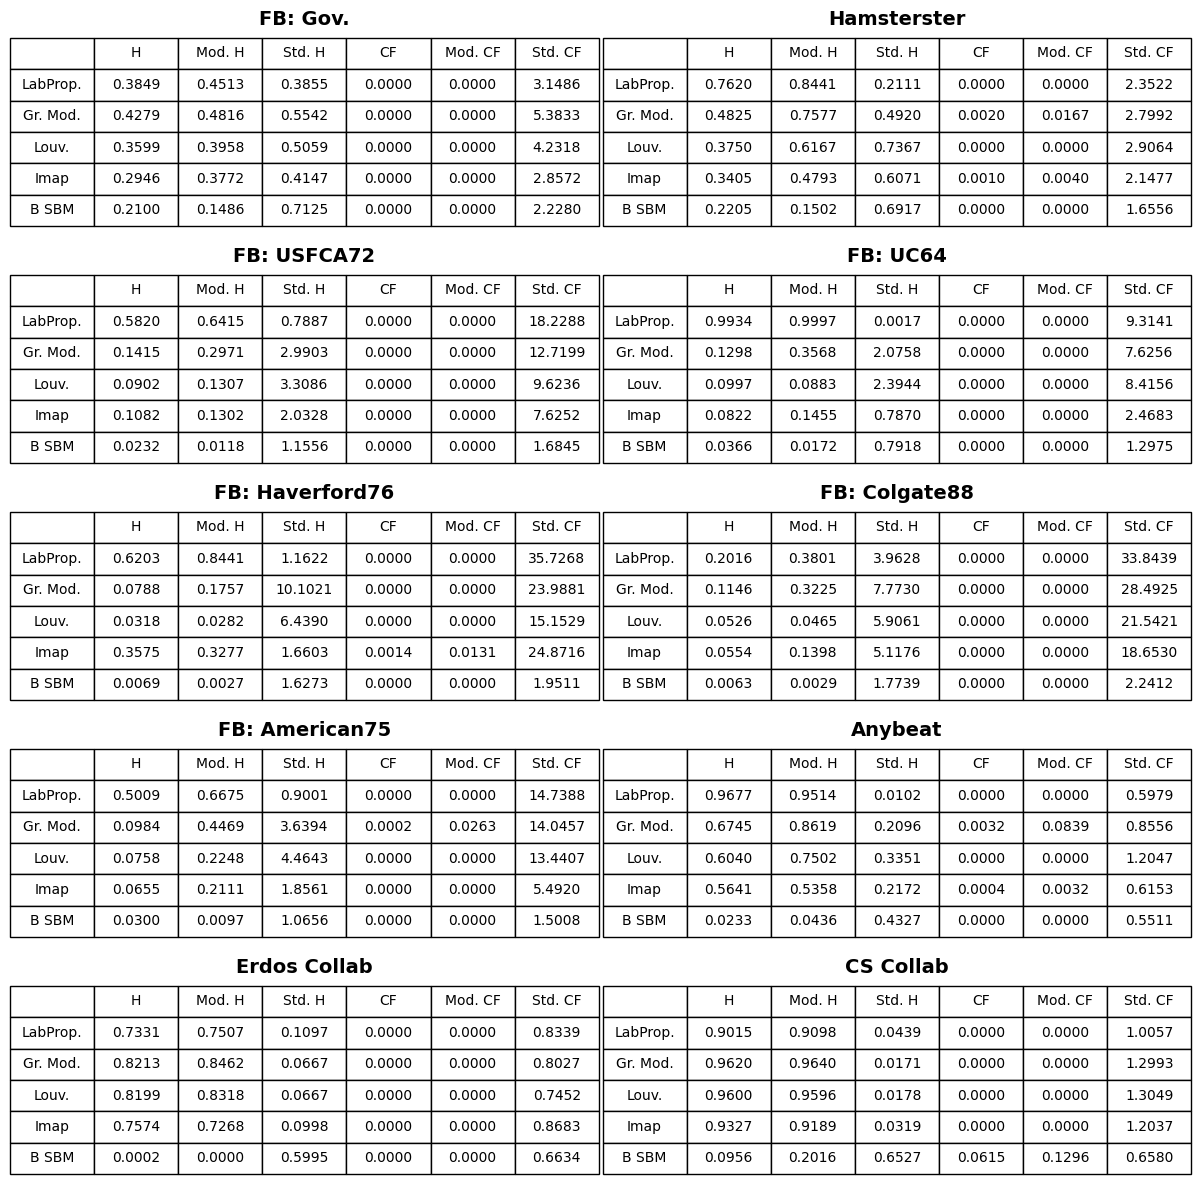

In [8]:
# Create a 2x3 subplot with an increased figure size
fig, axes = plt.subplots(5, 2, figsize=(12, 12))
axes = axes.flatten()
# Loop through DataFrames and display them in the subplot
for i, (title, df) in enumerate(df_6_ext.items()):
    axes[i].axis("off")  # Hide axes
    # Format values to 4 decimal places
    formatted_data = df.applymap(lambda x: f"{x:.4f}")
    # Convert DataFrame to include row labels
    table_data = formatted_data.copy()
    table_data.insert(0, "Index", table_data.index)  # Add row labels as first column
    # Create table with row and column labels
    table = axes[i].table(
        cellText=table_data.values,  # Data with row labels
        colLabels=[""] + list(df.columns),  # Empty first column for row labels
        cellLoc="center", 
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)  # Adjust table scaling
    # Set title closer to the table
    axes[i].set_title(title, fontsize=14, fontweight="bold", pad=5)
# Adjust layout to fit everything
plt.subplots_adjust(wspace=0.2, hspace=0.8)
plt.tight_layout()

# Data 7

In [12]:
# opening files
with open("GT_Tools_producing_data/Intermediate_outputs_7/data_7.pkl", "rb") as f:
    data_7= pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_7/sbm_7.pkl", "rb") as f:
    sbm_7 = pickle.load(f)

print(len(data_7))
print(len(sbm_7))

3
3


In [87]:
df_7_ext={}
df_7= {}
for name, g in data_7.items():
    # label propagation
    lb = nx.community.label_propagation_communities(g)
    cl_lb = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lb):
        for node in cluster_nodes:
            cl_lb[node] = cluster_id  # Assign cluster ID to node

    # greedy modularity
    nw = nx.community.greedy_modularity_communities(g)
    cl_nw = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(nw):
        for node in cluster_nodes:
            cl_nw[node] = cluster_id  # Assign cluster ID to node

    # Louvain
    lv= nx.community.louvain_communities(g)
    cl_lv = {}  # Initialize empty dictionary
    # Iterate over the detected communities and assign cluster labels
    for cluster_id, cluster_nodes in enumerate(lv):
        for node in cluster_nodes:
            cl_lv[node] = cluster_id  # Assign cluster ID to node
            
    # Infomap
    im= Infomap(two_level=True,silent=True, num_trials=20)
    im.add_networkx_graph(g)
    im.run()
    info = im.get_modules()
    
    # Bayesian SBM
    sbm = sbm_7[name]

    # Compute harmonic degrees
    G_lb, deg_h_lb, M_deg_h_lb, var_h_lb, av_h_lb, var_v_h_lb, Not_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb, av_cf_lb, var_v_cf_lb, Not_cf_lb= H_CF_cluster(g,cl_lb)
    G_nw, deg_h_nw, M_deg_h_nw, var_h_nw, av_h_nw, var_v_h_nw, Not_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw, av_cf_nw, var_v_cf_nw, Not_cf_nw= H_CF_cluster(g,cl_nw)
    G_lv, deg_h_lv, M_deg_h_lv, var_h_lv, av_h_lv, var_v_h_lv, Not_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv, av_cf_lv, var_v_cf_lv, Not_cf_lv= H_CF_cluster(g,cl_lv)
    G_im, deg_h_im, M_deg_h_im, var_h_im, av_h_im, var_v_h_im, Not_h_im, deg_cf_im, M_deg_cf_im, var_cf_im, av_cf_im, var_v_cf_im, Not_cf_im= H_CF_cluster(g,info)
    G_sbm, deg_h_sbm, M_deg_h_sbm, var_h_sbm, av_h_sbm, var_v_h_sbm, Not_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm, av_cf_sbm, var_v_cf_sbm, Not_cf_sbm= H_CF_cluster(g,sbm)
    # storing results in a dataframe
    val_lb = [deg_h_lb, M_deg_h_lb, var_h_lb, deg_cf_lb, M_deg_cf_lb, var_cf_lb]
    val_nw = [deg_h_nw, M_deg_h_nw, var_h_nw, deg_cf_nw, M_deg_cf_nw, var_cf_nw]
    val_lv = [deg_h_lv, M_deg_h_lv, var_h_lv, deg_cf_lv, M_deg_cf_lv, var_cf_lv]
    val_im = [deg_h_im, M_deg_h_im, var_h_im, deg_cf_im, M_deg_cf_im, var_cf_im]
    val_sbm = [deg_h_sbm, M_deg_h_sbm, var_h_sbm, deg_cf_sbm, M_deg_cf_sbm, var_cf_sbm]
    val = [ val_lb,val_nw, val_lv, val_im, val_sbm]
    df_ext = pd.DataFrame(val, index= Row_labels,  columns = Col_labels)
    df = df_ext.iloc[:, :3]
    df_7[name] = df
    df_7_ext[name] = df_ext
    print("ok")

ok
ok
ok


In [88]:
# Save the dictionary to a .pkl file
with open("Final_outputs/df_7.pkl", "wb") as f:
    pickle.dump(df_7, f)

# Save the dictionary to a .pkl file
with open("Final_outputs/df_7_ext.pkl", "wb") as f:
    pickle.dump(df_7_ext, f)

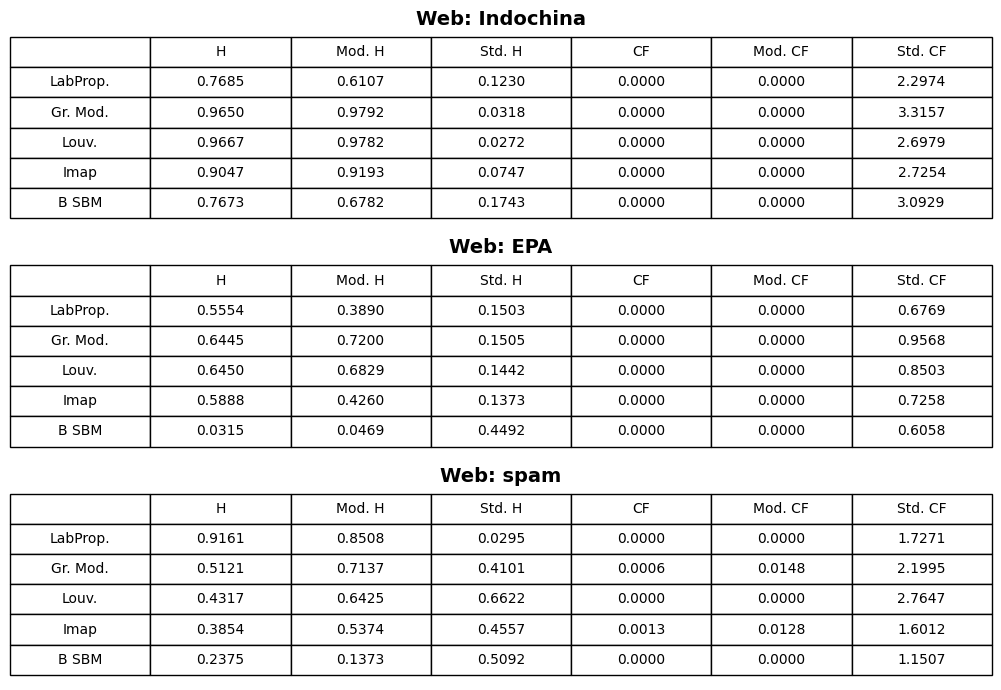

In [89]:
# Create a 2x3 subplot with an increased figure size
fig, axes = plt.subplots(3, 1, figsize=(10, 7))
axes = axes.flatten()
# Loop through DataFrames and display them in the subplot
for i, (title, df) in enumerate(df_7_ext.items()):
    axes[i].axis("off")  # Hide axes
    # Format values to 4 decimal places
    formatted_data = df.applymap(lambda x: f"{x:.4f}")
    # Convert DataFrame to include row labels
    table_data = formatted_data.copy()
    table_data.insert(0, "Index", table_data.index)  # Add row labels as first column
    # Create table with row and column labels
    table = axes[i].table(
        cellText=table_data.values,  # Data with row labels
        colLabels=[""] + list(df.columns),  # Empty first column for row labels
        cellLoc="center", 
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)  # Adjust table scaling
    # Set title closer to the table
    axes[i].set_title(title, fontsize=14, fontweight="bold", pad=5)
# Adjust layout to fit everything
plt.subplots_adjust(wspace=0.2, hspace=0.8)
plt.tight_layout()